## Setting up and Training NN 

### *–––– Set up ––––*

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

### *–––– reweighing the pT distribution ––––*

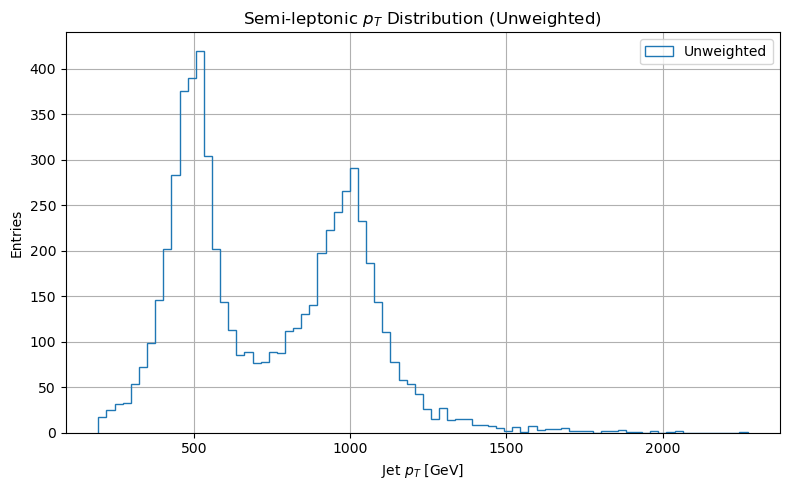

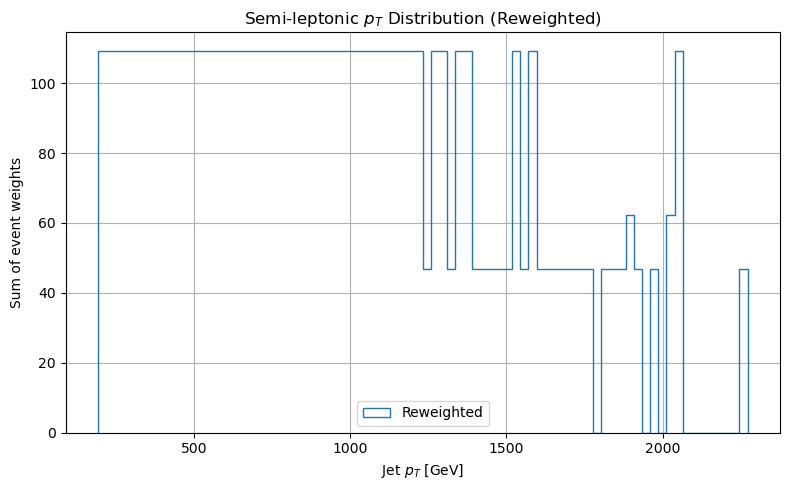

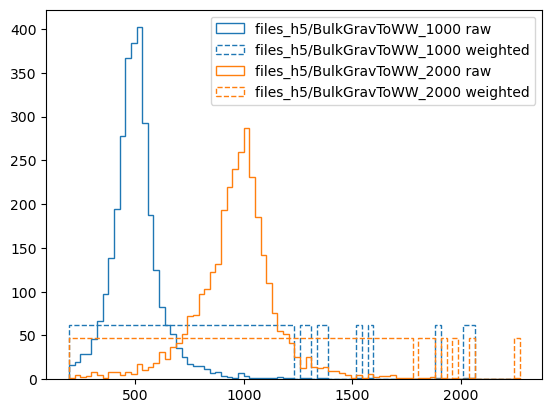

files_h5/BulkGravToWW_1000: sum(weights) = 3051.0  (should ≃ 3051)
files_h5/BulkGravToWW_2000: sum(weights) = 3182.0  (should ≃ 3182)


In [20]:
# ——— 1) CONFIGURATION ———

# List semi‑lep feature files & their mass labels:
mass_points = ["files_h5/BulkGravToWW_1000", "files_h5/BulkGravToWW_2000"]
semi_files  = [f"{m}_semi_features.h5"   for m in mass_points]
# Number of pT bins
n_bins = 80
bins = np.linspace(300, 1500, n_bins+1)

# ——— 2) LOAD & CONCAT ———

df_list = []
for mass, fn in zip(mass_points, semi_files):
    df = pd.read_hdf(fn, key="df")
    df["mass"] = mass
    df_list.append(df)
df_all = pd.concat(df_list, ignore_index=True)

# ——— 3) DEFINE COMMON pT BINS ———

pt_min, pt_max = df_all["pt"].min(), df_all["pt"].max()
bins = np.linspace(pt_min, pt_max, n_bins + 1)

df_all["pt_bin"] = pd.cut(df_all["pt"],bins=bins,labels=False,include_lowest=True)

# ——— 5) COMPUTE & ASSIGN WEIGHTS ———

df_all["weight"] = 0.0

for mass in mass_points:
    mask = df_all["mass"] == mass
    pts = df_all.loc[mask, "pt"]
    # raw histogram counts per bin
    counts, _ = np.histogram(pts, bins=bins)
    # avoid division by zero
    counts = np.where(counts == 0, 1, counts)
    # map each event to 1/counts[its_bin]
    w = 1.0 / counts[df_all.loc[mask, "pt_bin"].values]
    # normalize so sum(weights) == original N_events
    w *= len(w) / w.sum()
    df_all.loc[mask, "weight"] = w

# ––– 6) Plot UNWEIGHTED distribution and WEIGHTED distribution

plt.figure(figsize=(8,5))
plt.hist(df_all["pt"], bins=bins, histtype="step", label="Unweighted")
plt.xlabel("Jet $p_T$ [GeV]")
plt.ylabel("Entries")
plt.title("Semi‑leptonic $p_T$ Distribution (Unweighted)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df_all["pt"], bins=bins, weights=df_all["weight"], histtype="step", label="Reweighted")
plt.xlabel("Jet $p_T$ [GeV]")
plt.ylabel("Sum of event weights")
plt.title("Semi‑leptonic $p_T$ Distribution (Reweighted)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

for mass, color in zip(mass_points, ["C0","C1"]):
    mask = df_all.mass==mass
    plt.hist(df_all.pt[mask], bins=bins, histtype="step", label=f"{mass} raw", color=color)
    plt.hist(df_all.pt[mask], bins=bins, weights=df_all.weight[mask],
             histtype="step", linestyle="--", label=f"{mass} weighted", color=color)
plt.legend(); plt.show()

for mass in mass_points:
    total_w = df_all.loc[df_all.mass==mass, "weight"].sum()
    N       = len(df_all.loc[df_all.mass==mass])
    print(f"{mass}: sum(weights) = {total_w:.1f}  (should ≃ {N})")

In [ ]:
# ——— 7) CLEAN UP & SAVE ———
df_all.drop(columns="pt_bin", inplace=True)
outname = "semi_combined_reweighted.h5"
df_all.to_hdf(outname, key="df", mode="w")
print(f"Saved {outname} with {len(df_all)} events (weights added).")